Class distribution:
Pass
1    101
0     99
Name: count, dtype: int64
Logistic Regression Accuracy: 80.00%
Random Forest Accuracy: 85.00%

Classification Report (Random Forest):
              precision    recall  f1-score   support

        Fail       0.85      0.85      0.85        20
        Pass       0.85      0.85      0.85        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40


Feature Importance:
              Feature  Importance
0         Study_Hours    0.649615
1        Attendance_%    0.129476
2    Previous_Marks_%    0.124788
3  Assignment_Score_%    0.096121


C:\Users\raoh1\AppData\Local\Temp\ipykernel_16768\2661840476.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')



Sample Predictions:
{'Study_Hours': 3.0, 'Attendance_%': 84.2, 'Previous_Marks_%': 74.2, 'Assignment_Score_%': 57.8} -> FAIL
{'Study_Hours': 5.6, 'Attendance_%': 69.7, 'Previous_Marks_%': 88.8, 'Assignment_Score_%': 82.3} -> PASS
{'Study_Hours': 6.4, 'Attendance_%': 50.3, 'Previous_Marks_%': 89.8, 'Assignment_Score_%': 65.2} -> PASS
{'Study_Hours': 7.5, 'Attendance_%': 92.9, 'Previous_Marks_%': 76.7, 'Assignment_Score_%': 95.2} -> PASS
{'Study_Hours': 1.7, 'Attendance_%': 68.0, 'Previous_Marks_%': 52.3, 'Assignment_Score_%': 43.1} -> FAIL


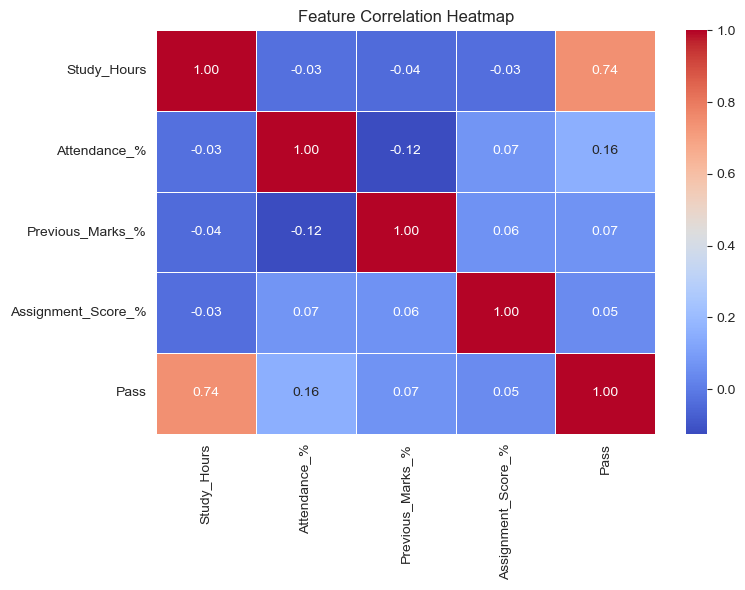

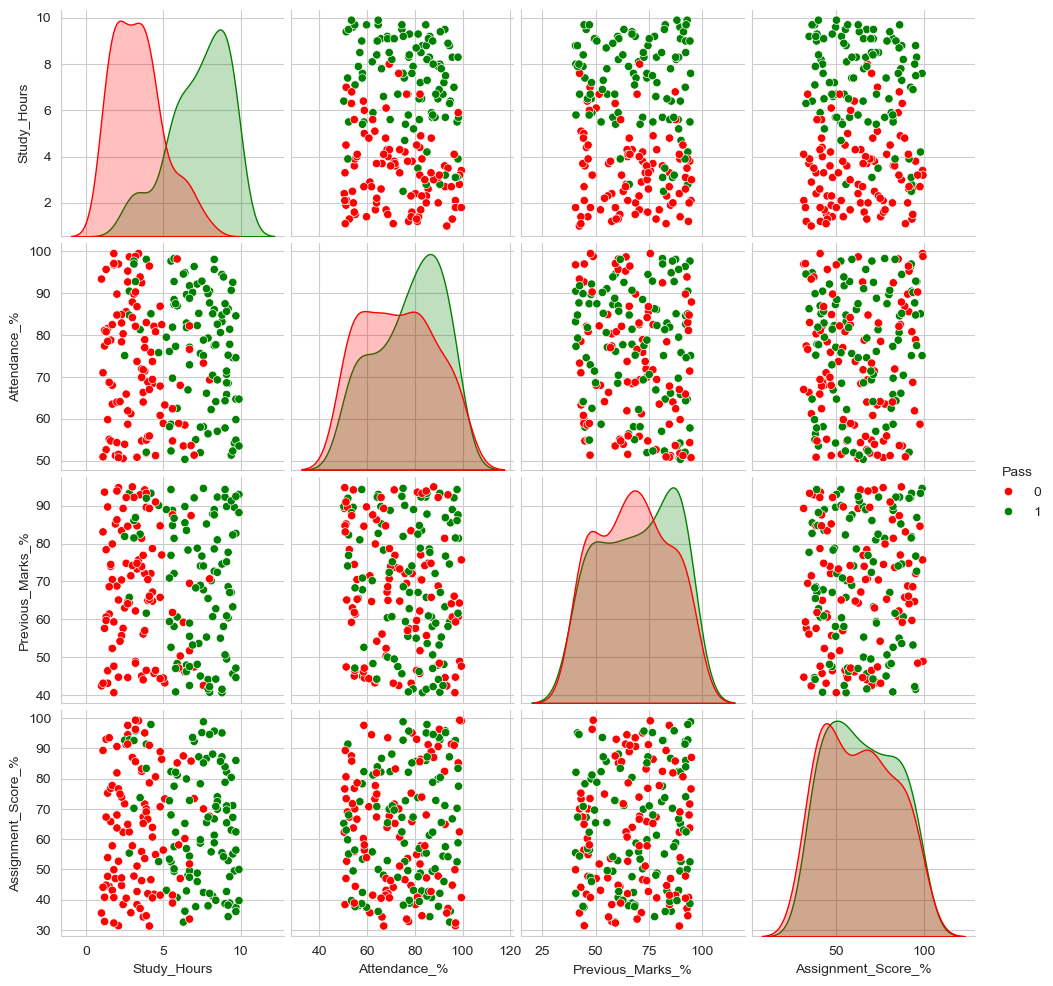

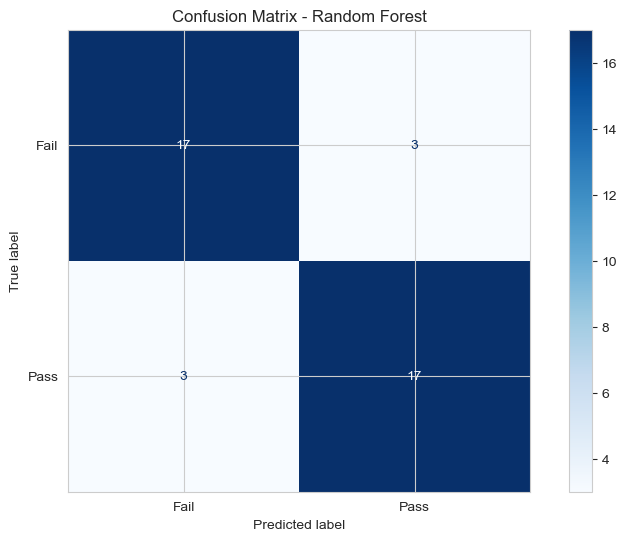

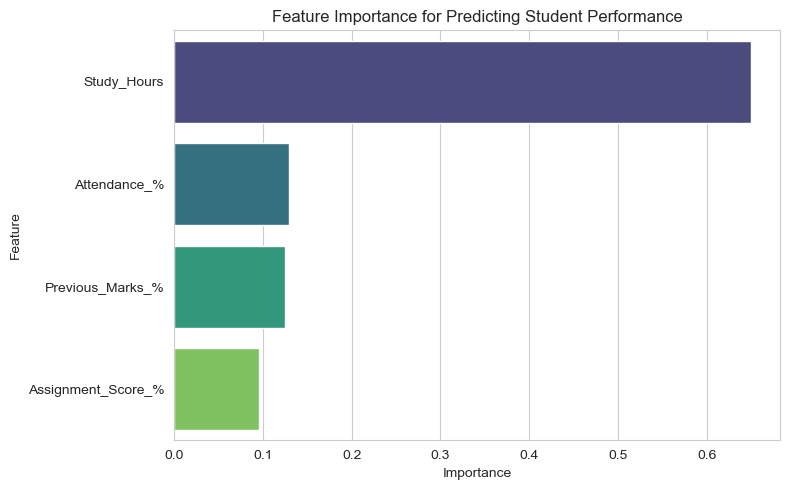

In [1]:
# Student Performance Prediction
# Virexo Internship - Week 1 Task (AI & ML)
# Author: Hamza Ali

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------------------
# 1. Create dataset
# ---------------------------------------------
np.random.seed(42)
n_students = 200

study_hours = np.random.uniform(1, 10, n_students)
attendance = np.random.uniform(50, 100, n_students)
prev_marks = np.random.uniform(40, 95, n_students)
assignment_score = np.random.uniform(30, 100, n_students)

# Weighted combination of features, threshold matched to the data's real range.
# Random noise is added so labels aren't a pure deterministic function of the
# same features used to train the model (avoids inflated, meaningless accuracy).
weighted_sum = (0.4 * study_hours) + (0.3 * attendance / 10) + (0.2 * prev_marks / 10) + (0.1 * assignment_score / 10)
noise = np.random.normal(0, 0.6, n_students)
prob_pass = 1 / (1 + np.exp(-(weighted_sum + noise - 6.4)))
labels = (prob_pass > 0.5).astype(int)

df = pd.DataFrame({
    'Study_Hours': study_hours.round(1),
    'Attendance_%': attendance.round(1),
    'Previous_Marks_%': prev_marks.round(1),
    'Assignment_Score_%': assignment_score.round(1),
    'Pass': labels
})
df.to_csv('student_performance_dataset.csv', index=False)

# ---------------------------------------------
# 2. Exploratory data analysis
# ---------------------------------------------
print("Class distribution:")
print(df['Pass'].value_counts())

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

sns.pairplot(df, hue='Pass', diag_kind='kde', palette=['red', 'green'])
plt.savefig('pairplot.png')

# ---------------------------------------------
# 3. Train/test split and scaling
# ---------------------------------------------
X = df.drop('Pass', axis=1)
y = df['Pass']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling matters for Logistic Regression; Random Forest is scale-invariant
# but applying it doesn't hurt.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------
# 4. Train models
# ---------------------------------------------
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

# ---------------------------------------------
# 5. Evaluation
# ---------------------------------------------
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix.png')

# ---------------------------------------------
# 6. Feature importance
# ---------------------------------------------
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Student Performance')
plt.tight_layout()
plt.savefig('feature_importance.png')

# ---------------------------------------------
# 7. Sample predictions
# ---------------------------------------------
sample_data = X_test.iloc[:5]
sample_scaled = scaler.transform(sample_data)
sample_preds = rf_model.predict(sample_scaled)

print("\nSample Predictions:")
for i in range(5):
    status = "PASS" if sample_preds[i] == 1 else "FAIL"
    print(f"{sample_data.iloc[i].to_dict()} -> {status}")